In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

# Part I - Logistic Regression for Binary Classification

## Exercise 1 - Load the dataset

* Load the diabetes dataset (`diabetes.csv`)
* Make a 70/30% train test partition of the dataset

*Suggestion:* I suggest you load it with pandas, but make a scikit-learn style dataset ($X$, $y$ numpy arrays)

In [2]:
# your code goes here:
data = pd.read_csv("diabetes.csv")
X = np.asarray(data.iloc[:,:-1])
y = np.asarray(data.iloc[:,-1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Excercise 2 - Implementing Logistic Regression

* In this exercise you will implement the logistic regression algorithm to learn the vector of weights $\vec{w}$.
* You will then plot the ROC curve, and calculate the AUROC (Area Under the ROC curve) using `sklearn.metrics.roc_auc_score()` for the testing set.

You can follow the structure for gradient descent as described in the previous labs and slides. Don't forget to write a function that calculates the sigmoid. You are not allowed in this exercise to use any existing functions.
* **Note that:** in the book and slides `y` is written as `t` and `y_hat` as `y`. 

Remember that $\nabla E(w) = \sum_{n=1}^N (y_n - t_n)\phi_n$ 

* _Tip:_ plot the loss during training to verify that everything is working properly.

In [78]:
# your code goes here:
# implement logistic regression using numpy following: $\nabla E(w) = \sum_{n=1}^N (y_n - t_n)\phi_n$
def sigmoid(a):
    return 1/(1 + np.exp(-a))

def cross_entropy(y_true, y_pred):

    err = -np.sum(y_true * np.log(y_pred + 1e-16) + (1 - y_true)*np.log(1 - y_pred + 1e-16))
    return err


def logistic_regression(X, t, eta, max_iter):
    np.random.seed(0)
    w = np.random.normal(scale=0.01, size=(X.shape[1]))

    ce_history = np.zeros(max_iter)

    for cada_epoca in range(max_iter):
        for n in range(len(t)):
            a_n = w.T.dot(X[n])
            y_n = sigmoid(a_n)

            gradiente = (y_n - t[n])*(X[n])
            w = w - eta * gradiente

        # Grabando o erro
        y_pred = sigmoid(X.dot(w))
        
        err_epoch = cross_entropy(t, y_pred)
        ce_history[cada_epoca] = err_epoch

    return w, ce_history

def TPR(y_true, y_pred):
    TP = np.sum(y_pred & y_true)
    P = np.sum(y_true)

    return TP/P

def FPR(y_true, y_pred):
    FP = np.sum(y_pred & (1 - y_true))
    N = np.sum(1 - y_true)

    return FP/N

Evaluate the performance of your model, plot the ROC curve and calculate the AUROC

In [43]:
from sklearn.metrics import roc_auc_score

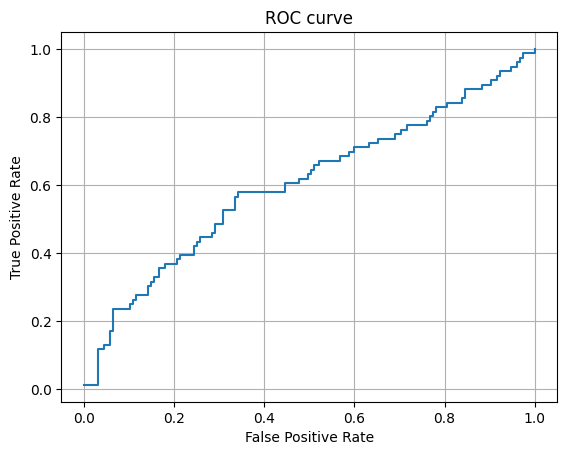

0.6021222410865874

In [ ]:
# your code goes here: 

# Adicionando Bias
X_train_f = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_f = np.c_[np.ones(X_test.shape[0]), X_test]


w, ce_history = logistic_regression(X_train_f, y_train, 3e-6, 10)
y_scores = sigmoid(X_test_f.dot(w))

# relembrando que os tresholds são os valores unicos das predições
thresholds = np.unique(y_scores)
T_PRL = [] #True Positive Rate List
F_PRL = [] #False Positive Rate List

# Calculando FPR e TPR para diferentes thresholds
for cada_t in thresholds:
    y_pred = y_scores >= cada_t

    T_PRL.append(TPR(y_test, y_pred))
    F_PRL.append(FPR(y_test, y_pred))


# plotando ROC curve
plt.plot(F_PRL, T_PRL)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")

plt.grid()
plt.show()

# calculando AUROC
roc_auc_score(y_test, y_scores)

# Part IV - Logistic Regression for multi-class classification

## Exercise 1 - Load the dataset
* Load the famous Iris dataset (using sklearn as shown below)
* Load the data in a matrix $X$ and the target in a vector $y$.
* Make a 70/30% train test partition of the dataset

In [100]:
from sklearn.datasets import load_iris

In [101]:
iris = load_iris()

Prepare $X$ and $y$

In [110]:
# your code goes here:
X = iris["data"]
y = iris["target"]

Split the data

In [131]:
# your code goes here:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Exercise 2 - Train the Logistic Regression model
Train your LogisticRegression multi-class classifier using the sklearn implementation. 
* To use the cross entropy loss function and softmax activation function, the `multi_class` parameter needs to be set to "multinomial"

In [119]:
from sklearn.linear_model import LogisticRegression

In [120]:
# Let's create an instance of the LogisticRegression classifier for multiclass classification
lr_iris = LogisticRegression(solver='newton-cg')

Fit the data

In [134]:
# your code goes here: 
clf = lr_iris.fit(X_train, y_train)

## Exercise 3 - Make predictions and evaluate the model
Use the `predict_proba()` method to obtain the output of the predictions for the testing set. The values are the output of the softmax activation function. 
* Remember that the highest value of each prediction corresponds to the actual predicted class.
* Write a function `get_predicted_class()` that transforms the vector of softmax outputs (obtained from `predict_proba()`) to a vector that just contains the predicted class. 
    - This function takes as input a matrix $\hat{Y}_{proba} \in \mathbb{R}^{m\times k}$ where $m$ is the number of samples in the testing set and $k$ is the number of classes.

As an example: if the softmax output is as follows: `Y_pred_sm = [[0.1,0.2,0.7], [0.4,0.3,0.3]]`, then `get_predicted_class(Y_pred_sm)` should return: `[2,0]` as the highest value for the 1st prediction is class 2 and for the 2nd prediction is class 0.

In [143]:
def get_predicted_class(Y_proba:np.ndarray):
    # your code goes here:
    y_pred =  Y_proba.argmax(axis=1)
    return y_pred

In [144]:
# complete the input argument for the function to obtain the predictions for the testing set.
y_pred_sm = clf.predict_proba(X_test)
y_pred = get_predicted_class(y_pred_sm)

Now calculate the accuracy in the testing set using `y_pred`
- Try calculating the accuracy without using the sklearn function :)

In [ ]:
# your code goes here:
np.mean(y_pred == y_test)

np.float64(1.0)